# 02 — Analysis (All Parties)

This notebook performs analysis **for all available parties** in the PDF and exports figures + summary tables.

We create:
- Overall distributions (all parties combined)
- Per-party distributions for:
  - **लिङ्ग**
  - **समावेशी समूह**
  - **नागरिकता जारी जिल्ला** (Top districts)
- Cross-tab: **लिङ्ग × समावेशी समूह** per party

All images are saved as PNG under `outputs/figures/`.


In [15]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path('..').resolve()
# Add project root to sys.path so `src` package can be imported
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.utils import slugify
from src.canonical import standardize_party_district, CANONICAL_PARTIES, CANONICAL_DISTRICTS

# Use a font that supports Devanagari (Nepali) script
plt.rcParams['font.family'] = 'Kohinoor Devanagari'

IN_CSV = PROJECT_DIR / 'data' / 'processed' / 'candidates.csv'
FIG_DIR = PROJECT_DIR / 'outputs' / 'figures'
TABLE_DIR = PROJECT_DIR / 'outputs' / 'tables'

df = pd.read_csv(IN_CSV)
df.head()


,party,serial,name,voter_no,लिङ्ग,समावेशी समूह,नागरिकता जारी जिल्ला,party_raw,district_raw
0,नेपाल मजदुर किसान पार्टी,1,हमालयवरलाल मूल,5336130,पुरुष,आदिवासी जनजाति,भक्तपुर,नेपाल मजदुर िकसान पाट,भतपुर
1,नेपाल मजदुर किसान पार्टी,2,हुछे मैया सुवाल,5360114,महिला,आदिवासी जनजाति,भक्तपुर,नेपाल मजदुर िकसान पाट,भतपुर
2,नेपाल मजदुर किसान पार्टी,3,नमा कुमार गु ङ,14660162,महिला,आदिवासी जनजाति,दैलेख,नेपाल मजदुर िकसान पाट,दैलेख
3,नेपाल मजदुर किसान पार्टी,4,राजे साद हाडा,5336657,पुरुष,आदिवासी जनजाति,भक्तपुर,नेपाल मजदुर िकसान पाट,भतपुर
4,नेपाल मजदुर किसान पार्टी,5,काशी नारायण डगं ोल,5435191,पुरुष,आदिवासी जनजाति,काठमाडौं,नेपाल मजदुर िकसान पाट,काठमाडौ


In [16]:
# Canonical cleanup for analysis
df = standardize_party_district(df)
df['लिङ्ग'] = df['लिङ्ग'].fillna('Unknown').astype(str).str.strip()
df['समावेशी समूह'] = df['समावेशी समूह'].fillna('Unknown').astype(str).str.strip()

print('Rows:', len(df), 'Parties:', df['party'].nunique(), 'Districts:', df['नागरिकता जारी जिल्ला'].nunique())
print('Unknown parties:', int((df['party'] == 'UNKNOWN_PARTY').sum()))
print('Unknown districts:', int((df['नागरिकता जारी जिल्ला'] == 'UNKNOWN_DISTRICT').sum()))

party_outside = sorted(set(df['party'].unique()) - set(CANONICAL_PARTIES) - {'UNKNOWN_PARTY'})
district_outside = sorted(set(df['नागरिकता जारी जिल्ला'].unique()) - set(CANONICAL_DISTRICTS) - {'UNKNOWN_DISTRICT'})
print('Outside-party values:', party_outside)
print('Outside-district values:', district_outside)

# Keep canonical-only rows for party/district reporting
analysis_df = df[(df['party'] != 'UNKNOWN_PARTY') & (df['नागरिकता जारी जिल्ला'] != 'UNKNOWN_DISTRICT')].copy()
print('Analysis rows (canonical party + district):', len(analysis_df))


Rows: 3200 Parties: 42 Districts: 66
Unknown parties: 896
Unknown districts: 239
Outside-party values: []
Outside-district values: []
Analysis rows (canonical party + district): 2135


In [17]:

# Helper: save a bar chart
def save_bar(series, title, xlabel, out_path, horizontal=False, max_categories=None):
    s = series.copy()
    if max_categories is not None and len(s) > max_categories:
        top = s.head(max_categories)
        other = pd.Series({"Other": s.iloc[max_categories:].sum()})
        s = pd.concat([top, other])
    plt.figure(figsize=(10, 6) if not horizontal else (10, 7))
    if horizontal:
        plt.barh(s.index[::-1], s.values[::-1])
        plt.ylabel("")
        plt.xlabel(xlabel)
    else:
        plt.bar(s.index, s.values)
        plt.xlabel(xlabel)
        plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=220)
    plt.close()
    return out_path


## Overall (all parties combined)

In [18]:

overall_gender = analysis_df["लिङ्ग"].value_counts()
overall_group = analysis_df["समावेशी समूह"].value_counts()
overall_district = analysis_df["नागरिकता जारी जिल्ला"].value_counts()

overall_gender.to_csv(TABLE_DIR / "overall_gender_counts.csv", header=["count"])
overall_group.to_csv(TABLE_DIR / "overall_inclusive_group_counts.csv", header=["count"])
overall_district.head(200).to_csv(TABLE_DIR / "overall_top200_district_counts.csv", header=["count"])

save_bar(overall_gender, "Overall Gender distribution (लिङ्ग) — All parties", "Count",
         FIG_DIR / "overall_gender.png")
save_bar(overall_group, "Overall Inclusive Group distribution (समावेशी समूह) — All parties", "Count",
         FIG_DIR / "overall_inclusive_group.png", max_categories=12)
save_bar(overall_district.head(25), "Top 25 Citizenship-Issuing Districts (नागरिकता जारी जिल्ला) — All parties", "Count",
         FIG_DIR / "overall_top25_districts.png", horizontal=True)

overall_gender, overall_group.head(10), overall_district.head(10)


(लिङ्ग
 महिला    1215
 पुरुष     920
 Name: count, dtype: int64,
 समावेशी समूह
 आदिवासी जनजाति    522
 खस आर्य           503
 ष                 409
 मधेशी             268
 दलत               227
 थारु              109
 मुिलम              93
 मिु                 4
 Name: count, dtype: int64,
 नागरिकता जारी जिल्ला
 काठमाडौं    180
 पर्सा       109
 मोरङ         87
 सिराहा       87
 धनुषा        86
 बारा         80
 सर्लाही      76
 झापा         75
 सुनसरी       68
 महोत्तरी     68
 Name: count, dtype: int64)

## Per-party analysis (loops over *all* parties)

In [19]:

parties = sorted(analysis_df["party"].unique())
len(parties), parties[:10]


(41,
 ['उन्नत लोकतन्त्र पार्टी',
  'गतिशील लोकतान्त्रिक पार्टी',
  'जन अधिकार पार्टी',
  'जनता लोकतान्त्रिक पार्टी, नेपाल',
  'जनता समाजवादी पार्टी, नेपाल',
  'जनप्रिय लोकतान्त्रिक पार्टी',
  'जनमत पार्टी',
  'जनादेश पार्टी नेपाल',
  'जातान्त्रिक पार्टी नेपाल',
  'नागरिक उन्मुक्ति पार्टी, नेपाल'])

In [20]:

# Per-party summaries + exports
per_party_summary = []

for party in parties:
    d = analysis_df[analysis_df["party"] == party].copy()
    if d.empty:
        continue
    party_slug = slugify(party)
    party_fig_dir = FIG_DIR / "party" / party_slug
    party_tbl_dir = TABLE_DIR / "party" / party_slug
    party_fig_dir.mkdir(parents=True, exist_ok=True)
    party_tbl_dir.mkdir(parents=True, exist_ok=True)

    # Counts
    g_counts = d["लिङ्ग"].value_counts()
    ig_counts = d["समावेशी समूह"].value_counts()
    dist_counts = d["नागरिकता जारी जिल्ला"].value_counts()

    # Save tables
    g_counts.to_csv(party_tbl_dir / "gender_counts.csv", header=["count"])
    ig_counts.to_csv(party_tbl_dir / "inclusive_group_counts.csv", header=["count"])
    dist_counts.head(50).to_csv(party_tbl_dir / "top50_district_counts.csv", header=["count"])

    # Charts
    save_bar(g_counts, f"{party} — Gender (लिङ्ग)", "Count", party_fig_dir / "gender.png")
    save_bar(ig_counts, f"{party} — Inclusive Group (समावेशी समूह)", "Count", party_fig_dir / "inclusive_group.png", max_categories=12)
    save_bar(dist_counts.head(15), f"{party} — Top 15 Citizenship-Issuing Districts (नागरिकता जारी जिल्ला)", "Count",
             party_fig_dir / "top15_districts.png", horizontal=True)

    # Cross-tab: gender x inclusive group
    ctab = pd.crosstab(d["समावेशी समूह"], d["लिङ्ग"])
    ctab.to_csv(party_tbl_dir / "crosstab_inclusive_group_by_gender.csv", encoding="utf-8")

    # Heatmap-like plot (matplotlib only)
    plt.figure(figsize=(8, 0.35*len(ctab) + 2))
    mat = ctab.values
    plt.imshow(mat, aspect="auto")
    plt.xticks(range(ctab.shape[1]), ctab.columns, rotation=45, ha="right")
    plt.yticks(range(ctab.shape[0]), ctab.index)
    plt.title(f"{party} — समावेशी समूह × लिङ्ग (counts)")
    # annotate
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            plt.text(j, i, str(mat[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(party_fig_dir / "heatmap_group_x_gender.png", dpi=220)
    plt.close()

    per_party_summary.append({
        "party": party,
        "candidates": len(d),
        "female": int((d['लिङ्ग'] == 'महिला').sum()),
        "male": int((d['लिङ्ग'] == 'पुरुष').sum()),
        "unique_districts": int(d["नागरिकता जारी जिल्ला"].nunique()),
    })

per_party_summary_df = pd.DataFrame(per_party_summary).sort_values("candidates", ascending=False)
per_party_summary_df.to_csv(TABLE_DIR / "per_party_summary.csv", index=False, encoding="utf-8")
per_party_summary_df.head(20)


,party,candidates,female,male,unique_districts
33,राष्ट्रिय जात पार्टी,104,53,51,46
21,नेपाल सद्भावना पार्टी,104,55,49,26
10,नेपाल कम्युनिष्ट पार्टी (एमाले),104,53,51,46
12,नेपाल कम्युनिष्ट पार्टी (मार्क्सवादी-लेनिनवादी),104,57,47,37
18,नेपाल मजदुर किसान पार्टी,103,56,47,40
36,श्रम संस्कृति पार्टी,103,55,48,41
23,नेपाली कम्युनिष्ट पार्टी,102,54,48,43
11,नेपाल कम्युनिष्ट पार्टी (माओवादी),102,54,48,54
35,राष्ट्रिय स्वतन्त्र पार्टी,101,58,43,41
6,जनमत पार्टी,101,54,47,23


## A quick overall visualization: Female share by party (top 30 by candidates)

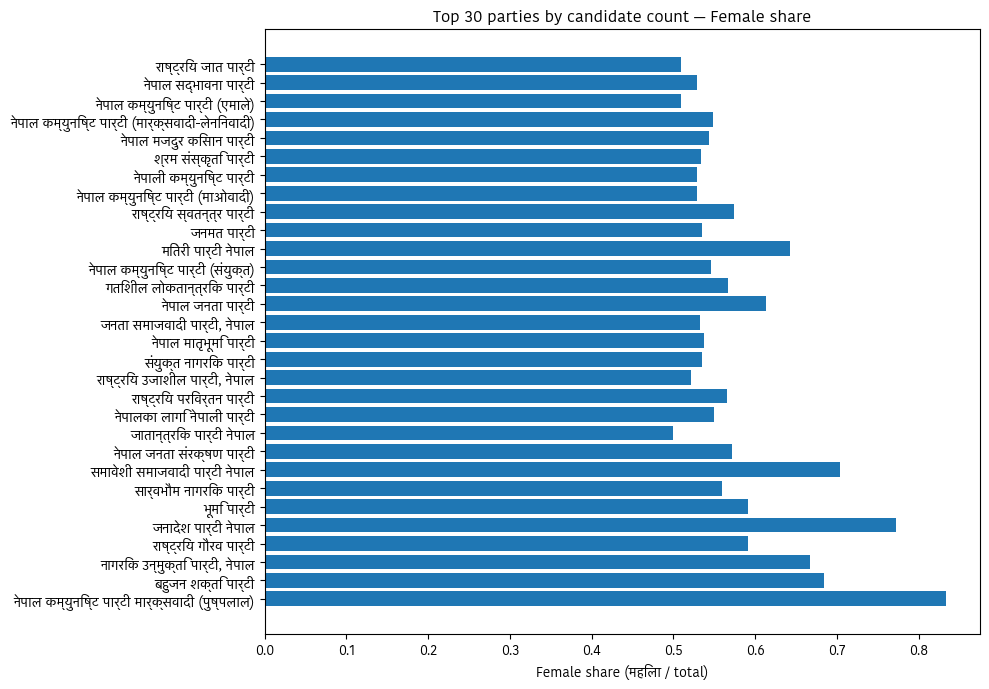

PosixPath('/Users/bikki/Downloads/nepal_pr_candidate_analysis/outputs/figures/top30_parties_female_share.png')

In [21]:

top_parties = per_party_summary_df.head(30).copy()
top_parties["female_share"] = top_parties["female"] / top_parties["candidates"]

plt.figure(figsize=(10, 7))
plt.barh(top_parties["party"][::-1], top_parties["female_share"][::-1])
plt.xlabel("Female share (महिला / total)")
plt.title("Top 30 parties by candidate count — Female share")
plt.tight_layout()
out = FIG_DIR / "top30_parties_female_share.png"
plt.savefig(out, dpi=220)
plt.show()
out


## Finished

All outputs are now in:
- `outputs/figures/`
- `outputs/tables/`
